Part 1

In [25]:
import pandas as pd

In [33]:
data = pd.read_csv(r"E:\\pradnya's programming\Domains\DataAnalytics\DA_clgAss\\customer_data.csv")

In [34]:
data.head()

,CustomerID,Age,Income,SpendingScore,Gender,Profession,MaritalStatus
0,1,56,31995,54,Male,Teacher,Single
1,2,69,44982,65,Male,Artist,Married
2,3,46,42875,51,Male,Lawyer,Married
3,4,32,40200,53,Male,Lawyer,Single
4,5,60,76481,36,Female,Student,Single


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     500 non-null    int64 
 1   Age            500 non-null    int64 
 2   Income         500 non-null    int64 
 3   SpendingScore  500 non-null    int64 
 4   Gender         500 non-null    object
 5   Profession     500 non-null    object
 6   MaritalStatus  500 non-null    object
dtypes: int64(4), object(3)
memory usage: 27.5+ KB


In [36]:
data['Profession'].value_counts()
data['Age'] = data['Age'].astype(float)

In [37]:
from sklearn.preprocessing import LabelEncoder
label_Encoder = LabelEncoder()
data['Gender'] = label_Encoder.fit_transform(data['Gender'])
data['Gender'].unique()

data['Profession'] = label_Encoder.fit_transform(data['Profession'])
data['Profession'].unique()

data['MaritalStatus'] = label_Encoder.fit_transform(data['MaritalStatus'])
data['MaritalStatus'].unique()

array([1, 0])

In [38]:
features = ['Age','Income','SpendingScore','Gender','Profession','MaritalStatus']
x = data[features]

In [39]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_scaled = scalar.fit_transform(x)


In [40]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    k = KMeans(n_clusters=i,random_state=42)
    k.fit(X_scaled)
    wcss.append(k.inertia_)



c:\Users\Pradnya\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Pradnya\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Pradnya\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Pradnya\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1024, in __init__
    self._execute_child(args, executable, preexec_fn, close

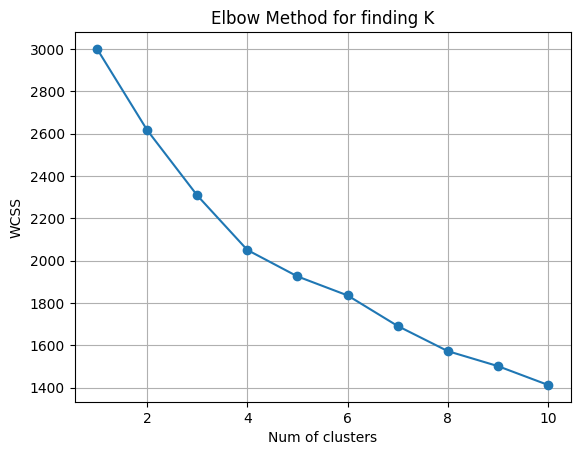

In [43]:
import matplotlib.pylab as plt
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method for finding K")
plt.xlabel('Num of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [44]:
k = KMeans(n_clusters=6,random_state=42)
k.fit(X_scaled)
labels = k.labels_
centroids = k.cluster_centers_

In [50]:
clusters = k.fit_predict(X_scaled)
data['clusters'] = clusters

In [51]:
for i in range(6):
    print(f"\n Cluster {i} sample data:")
    print(data[data['clusters'] == i].head())


 Cluster 0 sample data:
    CustomerID   Age  Income  SpendingScore  Gender  Profession  \
0            1  56.0   31995             54       1           5   
18          19  39.0   10000             24       1           0   
19          20  70.0   34634             22       0           4   
21          22  41.0   31283             56       0           1   
23          24  47.0   28547             36       0           3   

    MaritalStatus  clusters  
0               1         0  
18              1         0  
19              1         0  
21              1         0  
23              0         0  

 Cluster 1 sample data:
    CustomerID   Age  Income  SpendingScore  Gender  Profession  \
1            2  69.0   44982             65       1           0   
2            3  46.0   42875             51       1           3   
6            7  38.0   31086             29       1           1   
8            9  36.0   81832             11       1           3   
10          11  28.0   27209    

IndexError: index 4 is out of bounds for axis 0 with size 4

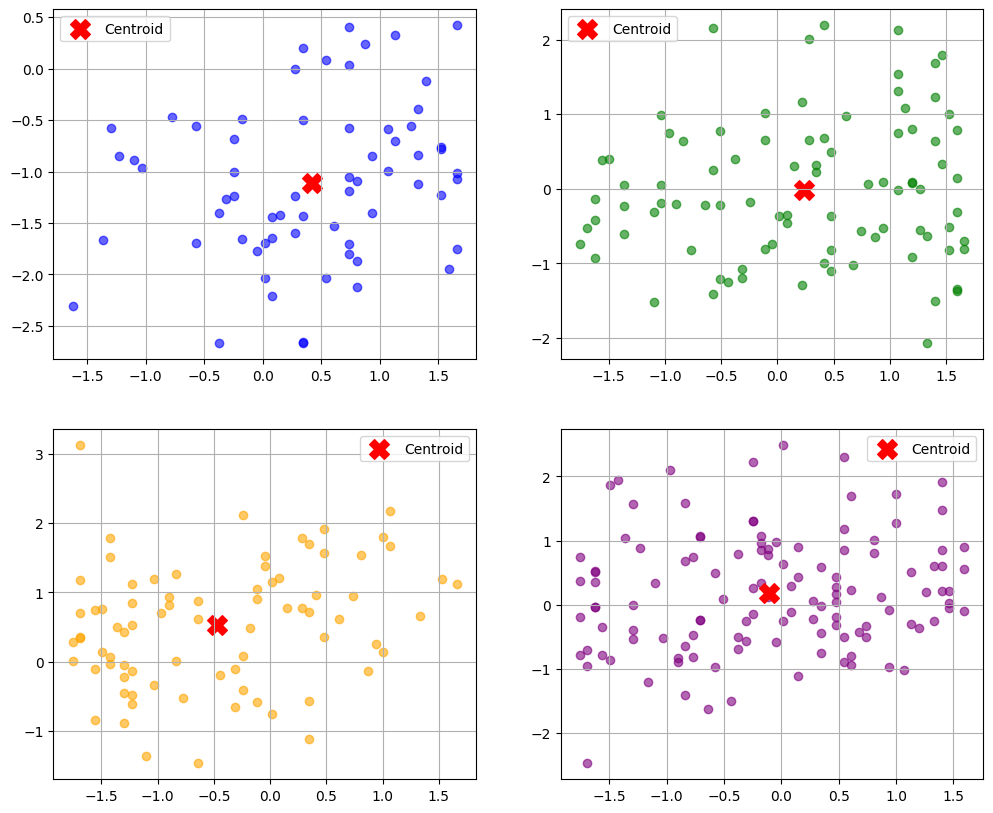

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Example cluster names – adjust based on your analysis
# cluster_names = {
#     0: 'Young Spenders',
#     1: 'High Income - High Spending',
#     2: 'Savers',
#     3: 'Low Income - Low Spending'
# }

colors = ['blue', 'green', 'orange', 'purple']
k = len(np.unique(clusters))

# 2x2 grid setup
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(k):
    ax = axes[i]
    ax.scatter(X_scaled[clusters == i, 0], X_scaled[clusters == i, 1],
               color=colors[i], alpha=0.6)
    ax.scatter(centroids[i, 0], centroids[i, 1], marker='X', s=200, c='red', label='Centroid')
    # ax.set_title(f"{cluster_names[i]}")
    # ax.set_xlabel('Age (Standardized)')
    # ax.set_ylabel('Income (Standardized)')
    ax.legend()
    ax.grid(True)

# Hide extra axes if clusters < 4
for j in range(k, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Customer Segmentation - ', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Part 2**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [ ]:
data = pd.read_csv("customer_data.csv")
data

,CustomerID,Age,Income,SpendingScore,Gender,Profession,MaritalStatus
0,1,56,31995,54,Male,Teacher,Single
1,2,69,44982,65,Male,Artist,Married
2,3,46,42875,51,Male,Lawyer,Married
3,4,32,40200,53,Male,Lawyer,Single
4,5,60,76481,36,Female,Student,Single
...,...,...,...,...,...,...,...
495,496,43,65215,64,Female,Lawyer,Married
496,497,70,22386,82,Male,Artist,Married
497,498,40,30806,95,Male,Teacher,Single
498,499,26,40627,38,Female,Student,Married


In [ ]:
data.head()

,CustomerID,Age,Income,SpendingScore,Gender,Profession,MaritalStatus
0,1,56,31995,54,Male,Teacher,Single
1,2,69,44982,65,Male,Artist,Married
2,3,46,42875,51,Male,Lawyer,Married
3,4,32,40200,53,Male,Lawyer,Single
4,5,60,76481,36,Female,Student,Single


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     500 non-null    int64 
 1   Age            500 non-null    int64 
 2   Income         500 non-null    int64 
 3   SpendingScore  500 non-null    int64 
 4   Gender         500 non-null    object
 5   Profession     500 non-null    object
 6   MaritalStatus  500 non-null    object
dtypes: int64(4), object(3)
memory usage: 27.5+ KB


In [ ]:
missing_values = data.isnull().sum()
missing_values

,0
CustomerID,0
Age,0
Income,0
SpendingScore,0
Gender,0
Profession,0
MaritalStatus,0


In [ ]:
data_cleaned = data.drop(columns=["CustomerID"])
data_cleaned

,Age,Income,SpendingScore,Gender,Profession,MaritalStatus
0,56,31995,54,Male,Teacher,Single
1,69,44982,65,Male,Artist,Married
2,46,42875,51,Male,Lawyer,Married
3,32,40200,53,Male,Lawyer,Single
4,60,76481,36,Female,Student,Single
...,...,...,...,...,...,...
495,43,65215,64,Female,Lawyer,Married
496,70,22386,82,Male,Artist,Married
497,40,30806,95,Male,Teacher,Single
498,26,40627,38,Female,Student,Married


In [ ]:
categorical_cols = ['Gender', 'Profession', 'MaritalStatus']
data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols)

In [ ]:
data_encoded = data_encoded.dropna()
data_encoded

,Age,Income,SpendingScore,Gender_Female,Gender_Male,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Lawyer,Profession_Student,Profession_Teacher,MaritalStatus_Married,MaritalStatus_Single
0,56,31995,54,False,True,False,False,False,False,False,True,False,True
1,69,44982,65,False,True,True,False,False,False,False,False,True,False
2,46,42875,51,False,True,False,False,False,True,False,False,True,False
3,32,40200,53,False,True,False,False,False,True,False,False,False,True
4,60,76481,36,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,43,65215,64,True,False,False,False,False,True,False,False,True,False
496,70,22386,82,False,True,True,False,False,False,False,False,True,False
497,40,30806,95,False,True,False,False,False,False,False,True,False,True
498,26,40627,38,True,False,False,False,False,False,True,False,True,False


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_encoded[['Age', 'Income']])
data_encoded['Segment'] = kmeans.labels_

In [ ]:
data['Segment'] = data_encoded['Segment']

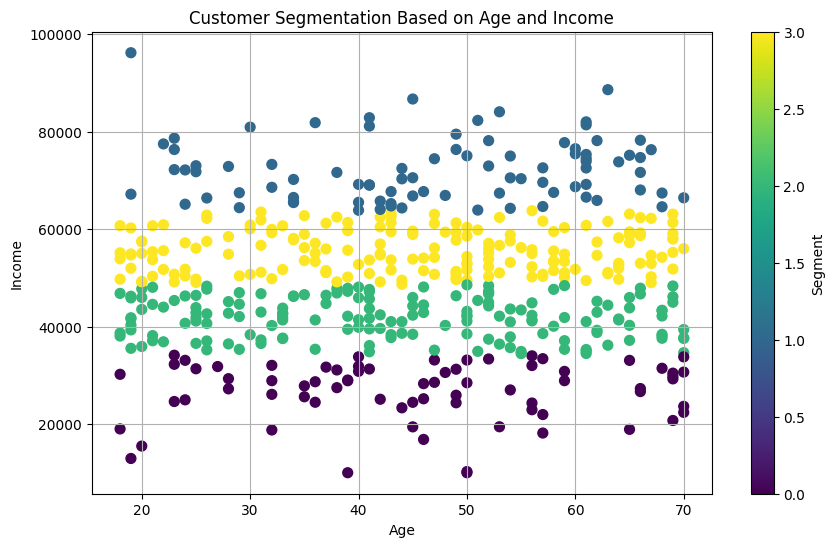

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Age'], data['Income'], c=data['Segment'], cmap='viridis', s=50)
plt.title('Customer Segmentation Based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.colorbar(label='Segment')
plt.grid(True)
plt.show()